In [1]:
%load_ext autoreload
%autoreload 2

# Figure 1

In [13]:
from src.utils import read_obs, crop_cell, get_shape_transform
from spatialdata import read_zarr, transform, aggregate, get_centroids
from spatialdata.models import Image2DModel, PointsModel, Labels2DModel
from spatialdata.transformations import get_transformation, set_transformation, Identity
import spatialdata_plot
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap
from scipy.ndimage import distance_transform_edt
import geopandas as gpd
import pandas as pd

## Figure 1E

In [3]:
sdata = read_zarr("/data/1417648792_sdata/1417648792_with_vs200_CAH_processed.zarr/")

version mismatch: detected: RasterFormatV02, requested: FormatV04
/opt/conda/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
/opt/conda/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/conda/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/conda/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_on

In [4]:
obs = read_obs("/data/spatial_adata/CAH_CAHmapping_scANVI_2025-07-23_35_sects.h5ad")

In [5]:
proto_index = obs["barcode"].astype(str) + "_" + obs["cell_id"].astype(str)
obs.index = proto_index
sdata["mapped_table"].obs["cell_idx"] = "1417648792" + "_" + sdata["mapped_table"].obs["cell_id"].astype(str)
obs = obs.loc[obs.index.intersection(sdata["mapped_table"].obs["cell_idx"]), ["Neighborhood_scANVI", "Subclass_scANVI", "Supertype_scANVI"]].astype("str").fillna("Unknown").astype("category")

In [6]:
sdata["mapped_table"].obs = sdata["mapped_table"].obs.merge(obs, left_on = "cell_idx", right_index = True, how = "outer")

In [7]:
sdata["mapped_table"].obs["Neighborhood_scANVI"].value_counts()

Neighborhood_scANVI
OPC-Oligo     13802
Vascular      13088
LGE           12443
Astro-Epen     6885
Immune         5261
MGE            1007
CGE              37
Name: count, dtype: int64

In [8]:
sdata_sample = crop_cell(sdata, "cell_boundaries", 'hahehemk-1', bounding_box_size = 256)

/opt/conda/lib/python3.12/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
  custom_palette = {
    'Astrocyte': '#FFC300',
    'Microglia-PVM': '#FF5733',
    'VLMC': '#5DADE2',
    'Endothelial': '#AED6F1',
    'Sst Chodl': '#27AE60',
    'CN ST18 GABA': '#A9DFBF',
    'STR D1 MSN': '#8E44AD',
    'STR D2 MSN': '#D2B4DE',
    'STR Hybrid MSN': '#E8DAEF',
    'OPC': '#FAD7A0',
    'Oligodendrocyte': '#D35400',
    'Ependymal':"#564860",
    'STR RSPO2 GABA':'#5b0e63',
    'Vip': '#1bc06a',
    'CN LAMP5-CXCL14 GABA':'#f6b5d1',
    "AQP4":cm.tab10.colors[0], 
    "DRD1":cm.tab10.colors[3],
    "DRD2":cm.tab10.colors[6],
                 }

In [10]:
sdata_sample['aligned_image_warped']

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 3, y: 256, x: 256)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 252.5 253.5 254.5 255.5
│         * x        (x) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 252.5 253.5 254.5 255.5
│       Data variables:
│           image    (c, y, x) uint16 393kB dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 3, y: 128, x: 128)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 249.0 251.0 253.0 255.0
│         * x        (x) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 249.0 251.0 253.0 255.0
│       Data variables:
│           image    (c, y, x) uint16 98kB dask.array<chunksize=(3, 128, 128), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 3, y: 64, x: 64)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 512B 2.0 6.0 10.0 14.0 18.0 ... 242.0 246.0 250.0 254.0
│         * x        (x) float64 512B 2.0 6.0 10.0 14.0 18.0 ... 242.0 246.0 250.0 254.0
│       Data variables:
│           image    (c, y, x) uint16 25kB dask.array<chunksize=(3, 64, 64), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 3, y: 32, x: 32)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 256B 4.0 12.0 20.0 28.0 ... 228.0 236.0 244.0 252.0
│         * x        (x) float64 256B 4.0 12.0 20.0 28.0 ... 228.0 236.0 244.0 252.0
│       Data variables:
│           image    (c, y, x) uint16 6kB dask.array<chunksize=(3, 32, 32), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 3, y: 16, x: 16)
        Coordinates:
          * c        (c) int64 24B 0 1 2
          * y        (y) float64 128B 8.0 24.0 40.0 56.0 ... 200.0 216.0 232.0 248.0
          * x        (x) float64 128B 8.0 24.0 40.0 56.0 ... 200.0 216.0 232.0 248.0
        Data variables:
            image    (c, y, x) uint16 2kB dask.array<chunksize=(3, 16, 16), meta=np.ndarray>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


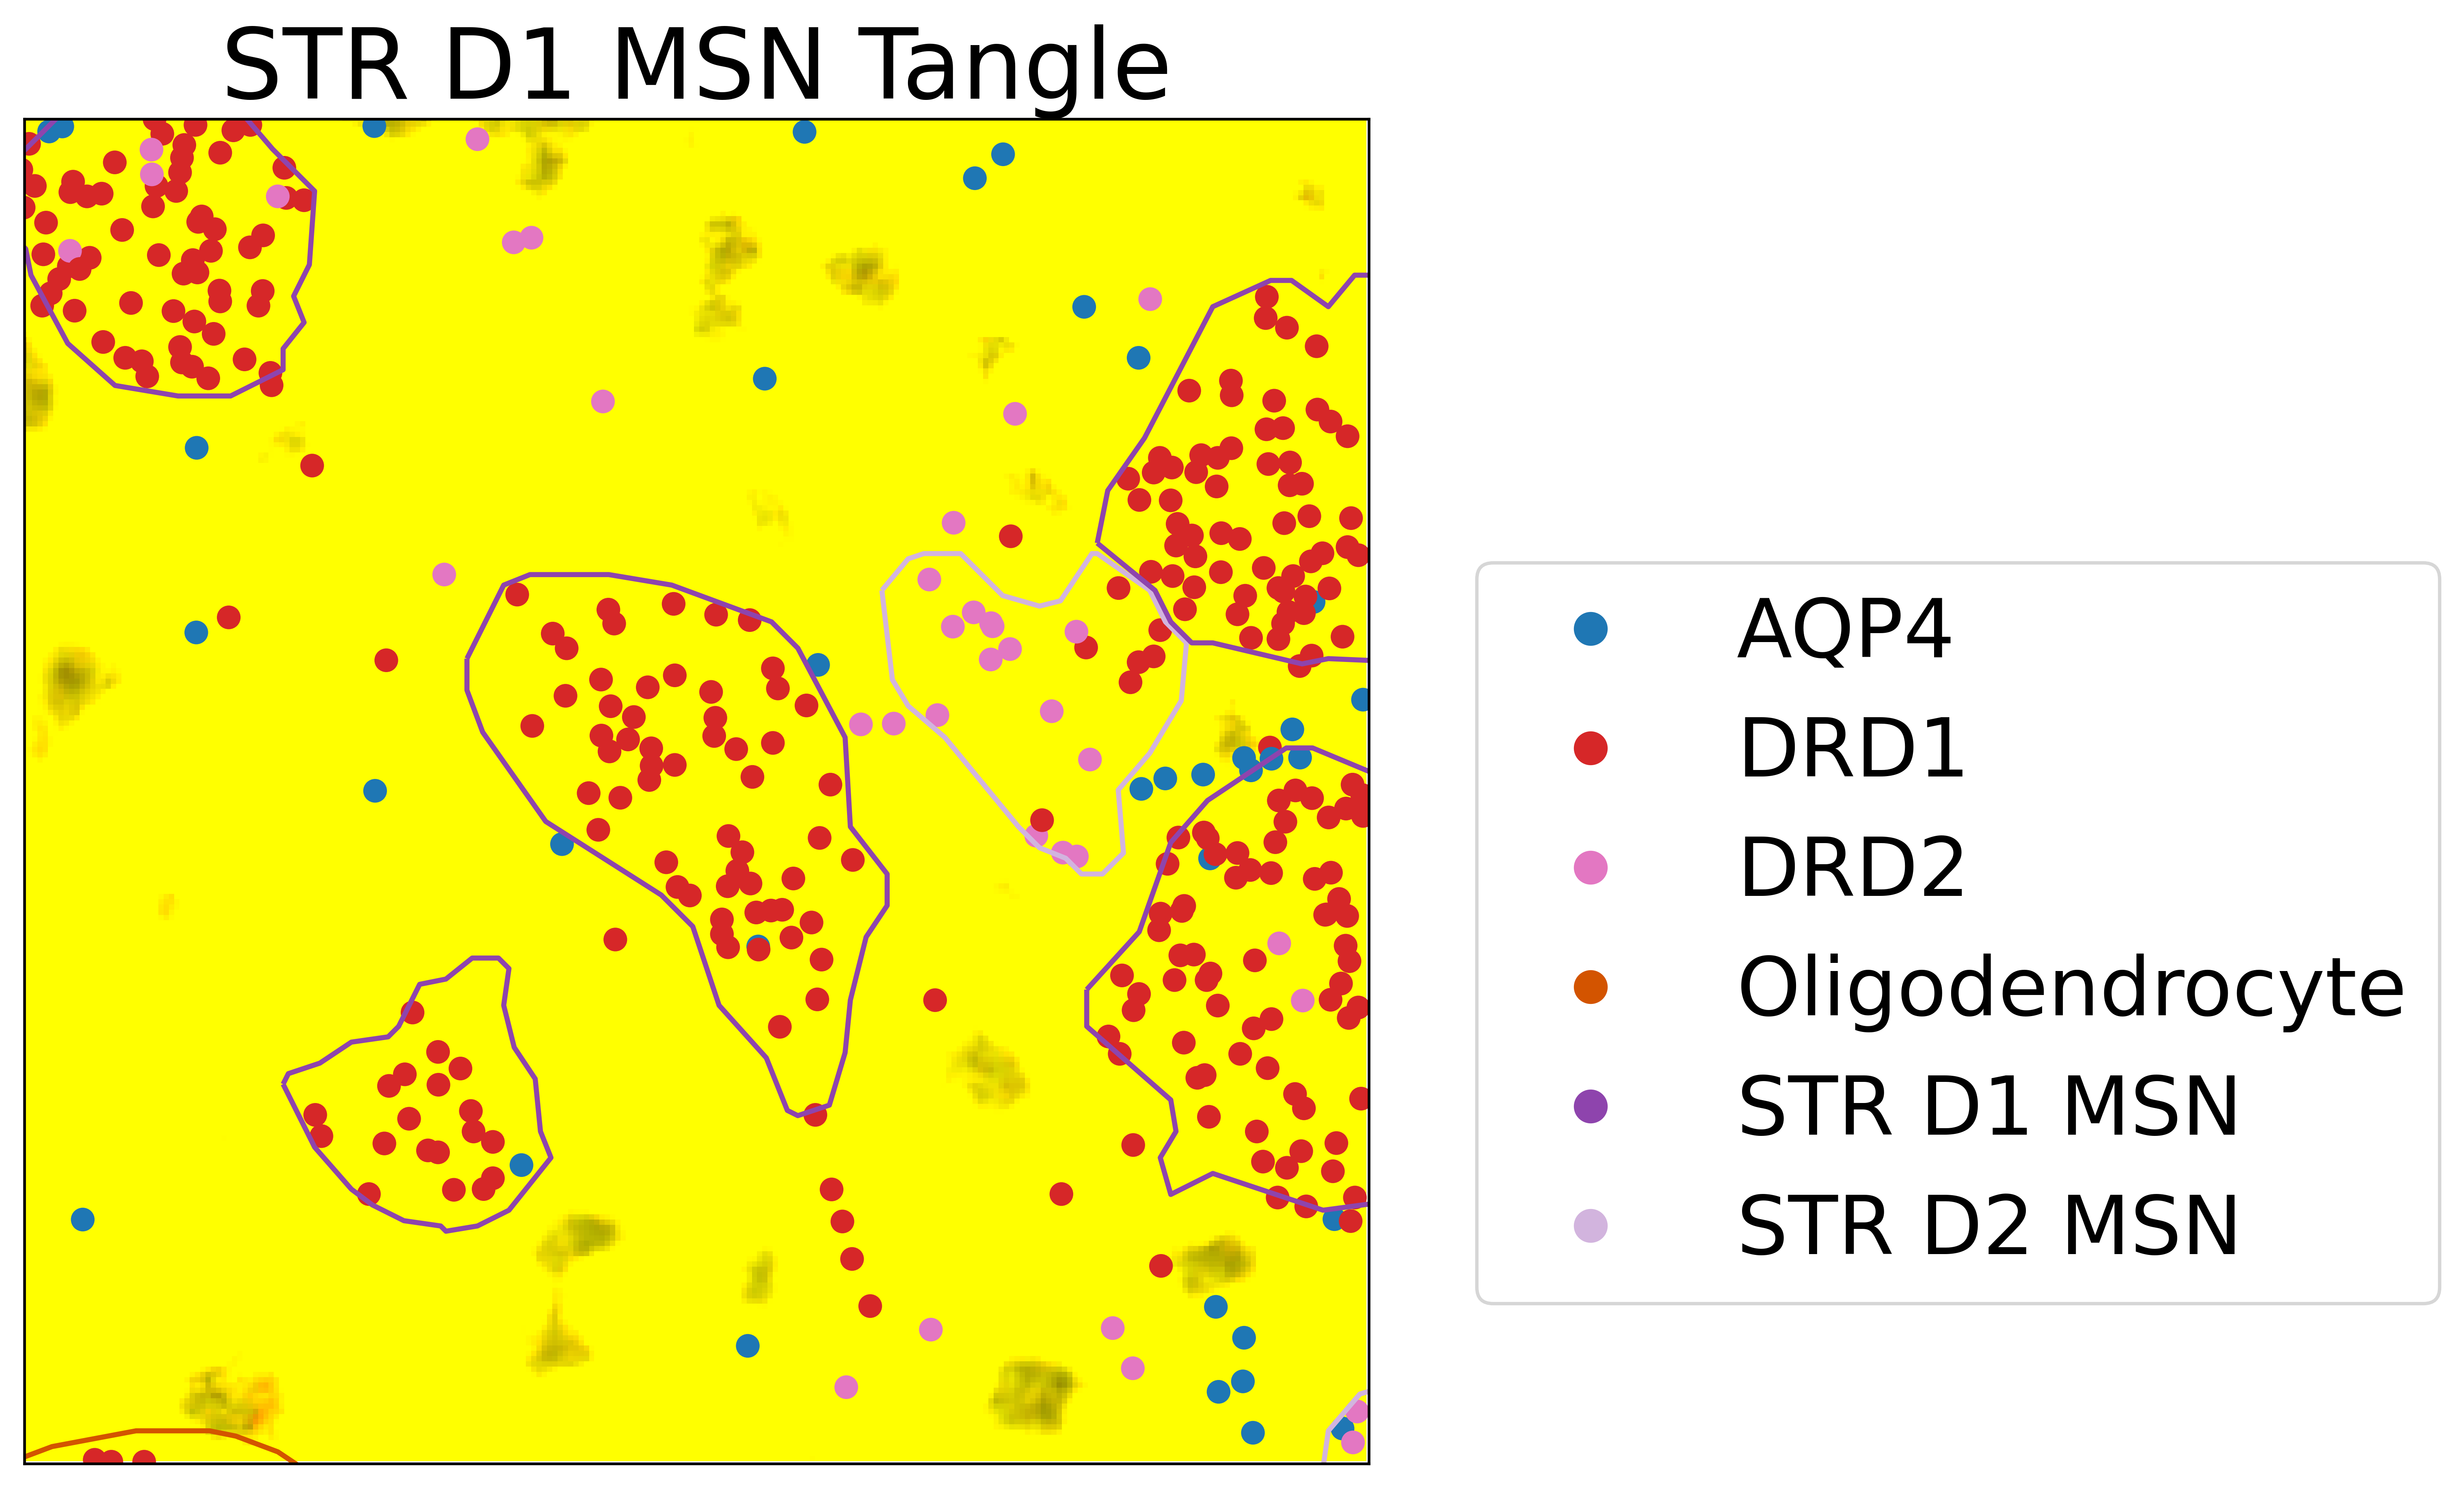

In [15]:
features = ['DRD1', 'DRD2', 'AQP4']
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    ax = (sdata_sample
        .pl.render_images("aligned_image_warped", channel = [1,2],norm = Normalize(5000, 10000))
        .pl.show(title = "STR D1 MSN Tangle", return_ax = True)
         )
    df = transform(sdata_sample['transcripts'], to_coordinate_system='global').compute()
    df = df[df['feature_name'].isin(features)]
    df['feature_name'] = df['feature_name'].cat.remove_unused_categories()
    # scatter = sns.scatterplot(x = 'x', y = 'y', hue = 'feature_name', data = df, s = 5, ax = ax)
    gdf = transform(sdata_sample["cell_boundaries"], to_coordinate_system="global")
    gdf.index =  "1417648792" + "_" + gdf.index
    gdf["Subclass"] = sdata["mapped_table"].obs.set_index("cell_idx")["Subclass_scANVI"]
    gdf["Subclass"] = gdf["Subclass"].cat.remove_unused_categories()
    gdf_2 = pd.concat({"geometry":gdf.boundary, "feature_name":gdf['Subclass']},axis = 1).set_geometry("geometry")
    transcript_df = pd.concat({"geometry":gpd.GeoSeries(gpd.points_from_xy(df['x'], df['y'])), "feature_name":df['feature_name'].reset_index(drop = True)}, axis = 1).set_geometry("geometry")
    total_df = pd.concat([gdf_2, transcript_df])
    cmap = ListedColormap([t[1] for t in sorted(custom_palette.items()) if t[0] in total_df["feature_name"].values])
    shape_plot = total_df.plot(column = 'feature_name', ax = ax, cmap = cmap, legend = True,legend_kwds = {"bbox_to_anchor":(1.05, 0.7), "loc":"upper left"})
    plt.xticks([])
    plt.yticks([])
    # plt.savefig("/scratch/d1_tau_tangle.svg", bbox_inches = 'tight')
    plt.show()

In [16]:
sdata_sample = crop_cell(sdata, "cell_boundaries", 'nemkaphe-1', bounding_box_size = 256)

/opt/conda/lib/python3.12/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [22]:
sdata_sample['aligned_image_warped']

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 3, y: 256, x: 256)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 252.5 253.5 254.5 255.5
│         * x        (x) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 252.5 253.5 254.5 255.5
│       Data variables:
│           image    (c, y, x) uint16 393kB dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 3, y: 128, x: 128)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 249.0 251.0 253.0 255.0
│         * x        (x) float64 1kB 1.0 3.0 5.0 7.0 9.0 ... 249.0 251.0 253.0 255.0
│       Data variables:
│           image    (c, y, x) uint16 98kB dask.array<chunksize=(3, 128, 128), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 3, y: 64, x: 64)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 512B 2.0 6.0 10.0 14.0 18.0 ... 242.0 246.0 250.0 254.0
│         * x        (x) float64 512B 2.0 6.0 10.0 14.0 18.0 ... 242.0 246.0 250.0 254.0
│       Data variables:
│           image    (c, y, x) uint16 25kB dask.array<chunksize=(3, 64, 64), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 3, y: 32, x: 32)
│       Coordinates:
│         * c        (c) int64 24B 0 1 2
│         * y        (y) float64 256B 4.0 12.0 20.0 28.0 ... 228.0 236.0 244.0 252.0
│         * x        (x) float64 256B 4.0 12.0 20.0 28.0 ... 228.0 236.0 244.0 252.0
│       Data variables:
│           image    (c, y, x) uint16 6kB dask.array<chunksize=(3, 32, 32), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 3, y: 16, x: 16)
        Coordinates:
          * c        (c) int64 24B 0 1 2
          * y        (y) float64 128B 8.0 24.0 40.0 56.0 ... 200.0 216.0 232.0 248.0
          * x        (x) float64 128B 8.0 24.0 40.0 56.0 ... 200.0 216.0 232.0 248.0
        Data variables:
            image    (c, y, x) uint16 2kB dask.array<chunksize=(3, 16, 16), meta=np.ndarray>

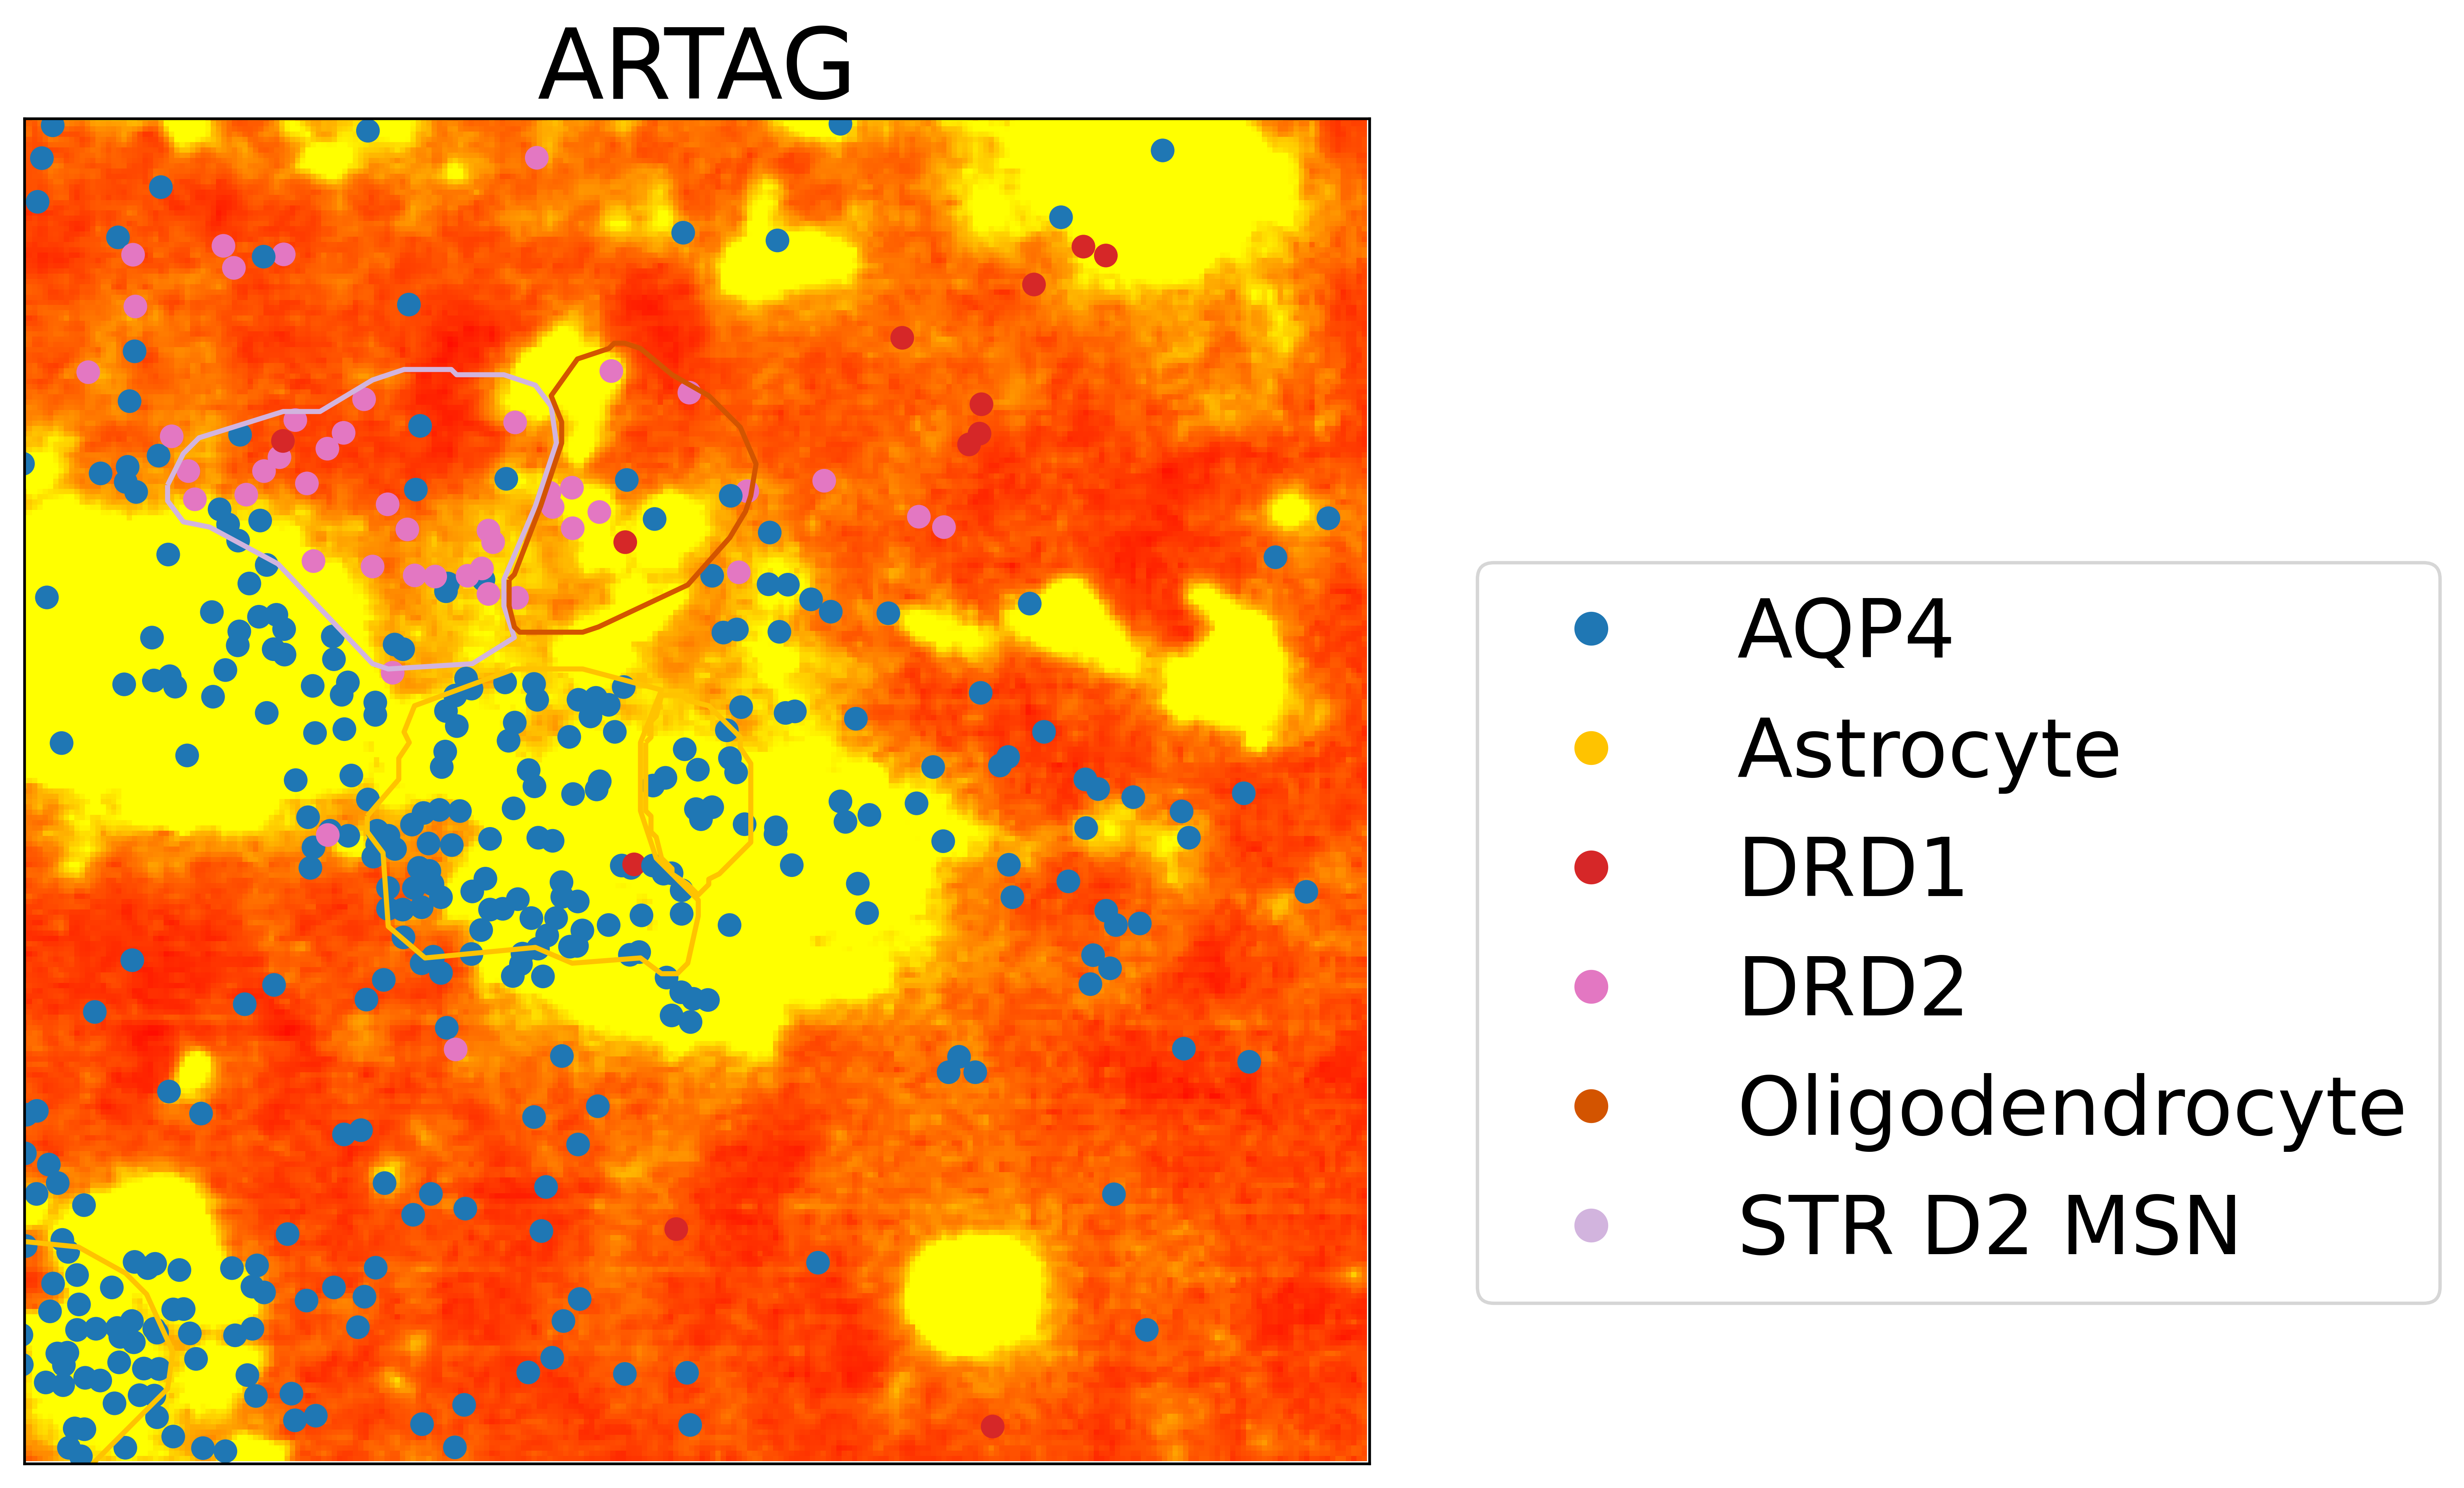

In [20]:
features = ['DRD1', 'DRD2', 'AQP4']
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    ax = (sdata_sample
        .pl.render_images("aligned_image_warped", channel = [1,2],  norm = Normalize(5000, 10000),)
        .pl.show(title = "ARTAG",  return_ax = True)
         )
    df = transform(sdata_sample['transcripts'], to_coordinate_system='global').compute()
    df = df[df['feature_name'].isin(features)]
    df['feature_name'] = df['feature_name'].cat.remove_unused_categories()
    # scatter = sns.scatterplot(x = 'x', y = 'y', hue = 'feature_name', data = df, s = 5, ax = ax)
    gdf = transform(sdata_sample["cell_boundaries"], to_coordinate_system="global")
    gdf.index =  "1417648792" + "_" + gdf.index
    gdf["Subclass"] = sdata["mapped_table"].obs.set_index("cell_idx")["Subclass_scANVI"]
    gdf["Subclass"] = gdf["Subclass"].cat.remove_unused_categories()
    gdf_2 = pd.concat({"geometry":gdf.boundary, "feature_name":gdf['Subclass']},axis = 1).set_geometry("geometry")
    transcript_df = pd.concat({"geometry":gpd.GeoSeries(gpd.points_from_xy(df['x'], df['y'])), "feature_name":df['feature_name'].reset_index(drop = True)}, axis = 1).set_geometry("geometry")
    total_df = pd.concat([gdf_2, transcript_df])
    cmap = ListedColormap([t[1] for t in sorted(custom_palette.items()) if t[0] in total_df["feature_name"].values])
    shape_plot = total_df.plot(column = 'feature_name', ax = ax, cmap = cmap, legend = True,legend_kwds = {"bbox_to_anchor":(1.05, 0.7), "loc":"upper left"})
    plt.xticks([])
    plt.yticks([])
    plt.savefig("/scratch/astro_tau_tangle.svg", bbox_inches = 'tight')
    plt.show()